In [1]:
import sys
sys.path.append(r'../')
import numpy as np
import matplotlib.pyplot as plt


from src.d_CSL import GcStar
from src.d_CSL import Visualize_on_topography
from src.dataload import *
from src.dataPreProcessing import replace_nan

# if variables are changed on the fly 
# from reloading import reloading
from tqdm.notebook import tqdm

/Users/sadiqadedayo/Documents/GC-extension/examples/../src/d_CSL.py:177: SyntaxWarning: invalid escape sequence '\d'
  with trimmed_arr = {X_{t}, X_{t-1}, \dots, X_{t-n}}^T


## Simulate data

An example ground truth connectivity matrix `A`

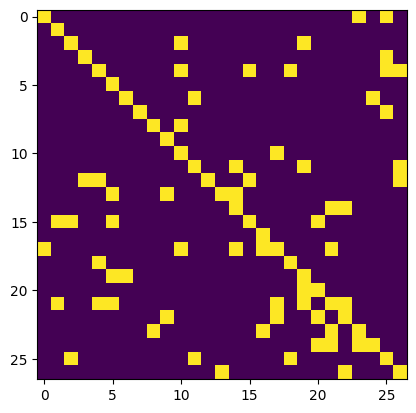

In [2]:
plt.imshow(adj_mtx(np.random.randint(25,40,1)[0])!=0)

## Analysis

In [ ]:
%%time
metrics, N_PASTS, num = [], list(range(1,8)), 20
for a in tqdm(range(num)):
    n_neur, l = np.random.randint(25,40,1)[0], np.random.randint(5000,15000,1)[0]
    alpha, beta, n_lags = 0.01, 0.001, 1
    
    
    # simulate data
    
    A = adj_mtx(n_neur)
    X = np.zeros((A.shape[0], l)).T
    X[0] = np.random.randn(A.shape[0])
    for i, row in enumerate(X[:-1]):
        X[i+1] = A @ X[i] + np.random.normal(0,0.25,A.shape[0])
    X=X.T
    
    print(f'Data {a} of {num} with {X.shape[0]} vars')
    
    # fit algorithm to data
    met = np.zeros((len(N_PASTS),4))
    for k, n_past in enumerate(N_PASTS):
        print(n_past)
        
        # intantiate the GcStar()
        gcstar = GcStar(n_perm = 1000, n_pasts = n_past, n_lags = n_lags, temporal = True, method="cgc")
        gcstar.fit(X, verbose=2)
        
        # compute metrics
        gcstar.get_connectivity_matrix()
        gcstar.compute_confusion_matrix(A)
        met[k] = gcstar.compute_metrics()
    metrics.append(met)

  0%|          | 0/20 [00:00<?, ?it/s]

INFO:src.d_CSL:Starting correlation_func
INFO:src.d_CSL:Starting inv_correlation_func
INFO:src.d_CSL:Waiting for correlation_func and inv_correlation_func to complete


Data 0 of 20 with 39 vars
1


DEBUG:numba.core.byteflow:bytecode dump:
>          0	NOP(arg=None, lineno=20)
           2	RESUME(arg=0, lineno=20)
           4	LOAD_CONST(arg=1, lineno=30)
           6	STORE_FAST(arg=3, lineno=30)
           8	LOAD_GLOBAL(arg=1, lineno=31)
          18	LOAD_ATTR(arg=2, lineno=31)
          38	LOAD_FAST(arg=0, lineno=31)
          40	LOAD_FAST(arg=1, lineno=31)
          42	CALL(arg=2, lineno=31)
          50	LOAD_CONST(arg=2, lineno=31)
          52	BINARY_SUBSCR(arg=None, lineno=31)
          56	STORE_FAST(arg=4, lineno=31)
          58	LOAD_FAST(arg=0, lineno=32)
          60	LOAD_ATTR(arg=5, lineno=32)
          80	CALL(arg=0, lineno=32)
          88	STORE_FAST(arg=5, lineno=32)
          90	LOAD_GLOBAL(arg=7, lineno=33)
         100	LOAD_FAST(arg=2, lineno=33)
         102	CALL(arg=1, lineno=33)
         110	GET_ITER(arg=None, lineno=33)
>        112	FOR_ITER(arg=147, lineno=33)
         116	STORE_FAST(arg=6, lineno=33)
         118	LOAD_GLOBAL(arg=0, lineno=35)
         128	LO

In [ ]:
for met in metrics:
    print(met)

In [ ]:
Metrics = np.zeros((num,7,4))
for i, met in enumerate(metrics):
    Metrics[i] = met
np.mean(Metrics[:,0,0])

In [ ]:
np.mean(Metrics,axis=0)

In [ ]:
fig, ax = plt.subplots(1, 4, figsize = (12, 3))
labels = ['Accuracy', 'Precision', 'Recall', 'FPR']
lab = ['$\mu_{acc}$','$\mu_{prec}$', '$\mu_{rec}$', '$\mu_{FPR}$']
for i in range(Metrics.shape[2]):
    ax[i].plot(range(1, 1 + Metrics.shape[1]), 
               np.mean(Metrics, axis = 0)[:, i],
               marker = '.', label = lab[i])
    
    ax[i].errorbar(range(1, 1 + Metrics.shape[1]), 
                   np.mean(Metrics, axis = 0)[:, i], 
                   yerr = np.std(Metrics, axis = 0)[:, i], 
                   fmt='o')
    ax[i].set_xticks(range(1,1+Metrics.shape[1]), 
                     list(range(1, 1+Metrics.shape[1])))
    ax[i].set_xlabel('$n_{pasts}$')
    ax[i].set_ylabel('%', rotation = 180)
    ax[i].set_title(f'{labels[i]}')
    ax[i].legend()
    plt.tight_layout()